In [2]:
# Cell 1: Data Loading and Initial Inspection for Regression

import pandas as pd
import numpy as np
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting data loading and initial inspection for regression model...")

try:
    # Assuming the dataset is in the current working directory
    df_reg = pd.read_csv('data/Hourly_Weather_Dataset.csv')
    logging.info("Hourly_Weather_Dataset.csv loaded successfully for regression.")

    print("\n--- Initial DataFrame Info (Regression) ---")
    df_reg.info()

    print("\n--- First 5 Rows of the DataFrame (Regression) ---")
    print(df_reg.head())

    print("\n--- Descriptive Statistics of Numerical Columns (Regression) ---")
    print(df_reg.describe())

    print("\n--- Check for Missing Values (Regression) ---")
    print(df_reg.isnull().sum())

    # Check the unique values and distribution of the 'Severity' column
    print("\n--- Unique values and distribution of 'Severity' (Regression Target) ---")
    print(df_reg['Severity'].value_counts())
    print(df_reg['Severity'].describe())

except FileNotFoundError:
    print("Error: 'Hourly_Weather_Dataset.csv' not found. Please ensure the file is in the correct directory.")
    df_reg = None # Set df_reg to None to prevent errors in subsequent cells
except Exception as e:
    print(f"An error occurred during data loading: {e}")
    df_reg = None

print("\nData loading and initial inspection complete for regression model.")

Starting data loading and initial inspection for regression model...


2025-07-28 01:50:27,871 - INFO - Hourly_Weather_Dataset.csv loaded successfully for regression.



--- Initial DataFrame Info (Regression) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40711 entries, 0 to 40710
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        40711 non-null  object 
 1   time                        40711 non-null  object 
 2   Severity                    40711 non-null  float64
 3   temperature_2m              40711 non-null  float64
 4   relative_humidity_2m        40711 non-null  float64
 5   precipitation               40711 non-null  float64
 6   surface_pressure            40711 non-null  float64
 7   cloud_cover                 40711 non-null  float64
 8   wind_speed_10m              40711 non-null  float64
 9   soil_temperature_0_to_7cm   40711 non-null  float64
 10  soil_temperature_7_to_28cm  40711 non-null  float64
 11  soil_moisture_0_to_7cm      40711 non-null  float64
 12  soil_moisture_7_to_28cm     40711 non-null 

In [27]:
# Cell 2: Data Loading, Preprocessing, Feature Engineering, and Splitting (REVISED for NaN Handling)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
print("Starting Cell 2: Data Loading, Preprocessing, Feature Engineering, and Splitting (Revised NaN Handling)...")

try:
    # --- 1. Load the dataset ---
    df_reg = pd.read_csv('data/Hourly_Weather_Dataset.csv')
    logging.info("Dataset 'Hourly_Weather_Dataset.csv' loaded as df_reg successfully.")

    print("Starting comprehensive feature engineering and preprocessing for regression...")

    df_processed_reg = df_reg.copy()

    # --- 1.1 Handle Date and Time Features and Chronological Sort ---
    df_processed_reg['datetime'] = pd.to_datetime(df_processed_reg['date'] + ' ' + df_processed_reg['time'])
    
    # CRITICAL for time series: Sort by datetime before creating lag/rolling features and splitting
    df_processed_reg = df_processed_reg.sort_values(by='datetime').reset_index(drop=True)
    logging.info("DataFrame sorted chronologically by 'datetime'.")

    # --- 1.2 Initial NaN Handling (on the full DataFrame before feature engineering) ---
    # This ensures that 'Severity' and other core columns are aligned from the start.
    initial_rows = len(df_processed_reg)
    df_processed_reg.ffill(inplace=True) # Forward fill any original NaNs
    df_processed_reg.bfill(inplace=True) # Backward fill any leading NaNs
    # Dropping rows with any remaining NaNs after ffill/bfill, which should be minimal
    df_processed_reg.dropna(inplace=True)
    df_processed_reg.reset_index(drop=True, inplace=True)
    logging.info(f"Initial NaN handling (ffill/bfill and dropna) completed. {initial_rows - len(df_processed_reg)} rows dropped.")


    # Extract temporal features
    df_processed_reg['hour_of_day'] = df_processed_reg['datetime'].dt.hour
    df_processed_reg['day_of_week'] = df_processed_reg['datetime'].dt.dayofweek
    df_processed_reg['month'] = df_processed_reg['datetime'].dt.month
    df_processed_reg['day_of_year'] = df_processed_reg['datetime'].dt.dayofyear
    df_processed_reg['week_of_year'] = df_processed_reg['datetime'].dt.isocalendar().week.astype(int)
    
    # Drop original date and time columns
    df_processed_reg = df_processed_reg.drop(columns=['date', 'time', 'datetime'])
    logging.info("Temporal features extracted and original datetime columns dropped.")

    # --- 2. Separate Target Variable ('Severity') ---
    global y_reg # Make y_reg global for potential other uses if needed
    y_reg = df_processed_reg['Severity']
    
    # Drop 'Severity' from features
    X_reg = df_processed_reg.drop(columns=['Severity'])
    logging.info("'Severity' column separated as target.")
    print(f"Length of X_reg after separation: {len(X_reg)}, Length of y_reg after separation: {len(y_reg)}")


    # --- 3. Encode 'forest_fire' (now a feature) ---
    X_reg['forest_fire_encoded'] = X_reg['forest_fire'].map({'N': 0, 'Y': 1})
    X_reg = X_reg.drop(columns=['forest_fire'])
    logging.info("'forest_fire' column encoded to 0/1 and included as a feature.")

    # --- 4. Generate Diverse FWI-like and Lag/Rolling Features ---
    logging.info("Generating diverse FWI-like and Lag/Rolling features...")

    # Ensure relevant columns are numeric for calculations
    core_numeric_features = [
        'temperature_2m', 'relative_humidity_2m', 'precipitation', 
        'surface_pressure', 'cloud_cover', 'wind_speed_10m',
        'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
        'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm'
    ]
    
    for col in core_numeric_features:
        X_reg[col] = pd.to_numeric(X_reg[col], errors='coerce') # Coerce non-numeric to NaN

    # FWI-like Features (Using the user's specified formula)
    X_reg['dryness_index'] = X_reg['temperature_2m'] * (100 - X_reg['relative_humidity_2m']) / 100
    X_reg['wind_dryness_factor'] = X_reg['wind_speed_10m'] * X_reg['dryness_index']
    X_reg['avg_soil_moisture'] = (X_reg['soil_moisture_0_to_7cm'] + X_reg['soil_moisture_7_to_28cm']) / 2
    X_reg['avg_soil_temp'] = (X_reg['soil_temperature_0_to_7cm'] + X_reg['soil_temperature_7_to_28cm']) / 2
    logging.info("Basic FWI-like features created.")

    # Lag Features (Aligned with user's specified lag periods and features)
    lag_periods = [1, 3, 6, 12, 24, 48]
    for col in ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'dryness_index', 'precipitation']:
        for lag in lag_periods:
            X_reg[f'{col}_lag{lag}h'] = X_reg[col].shift(lag)
    logging.info(f"Lag features for {lag_periods} hours created for key meteorological features.")

    # Rolling Window Features (Aligned with user's specific naming and .shift(1))
    rolling_windows = [6, 12, 24, 48]
    
    for window in rolling_windows:
        X_reg[f'temp_{window}h_avg'] = X_reg['temperature_2m'].rolling(window=window, min_periods=1).mean().shift(1)
        X_reg[f'humidity_{window}h_avg'] = X_reg['relative_humidity_2m'].rolling(window=window, min_periods=1).mean().shift(1)
        X_reg[f'precip_{window}h_sum'] = X_reg['precipitation'].rolling(window=window, min_periods=1).sum().shift(1)
        X_reg[f'wind_max_{window}h'] = X_reg['wind_speed_10m'].rolling(window=window, min_periods=1).max().shift(1)
        logging.info(f"Rolling window features (avg, sum, max) for {window} hours created.")

    # --- 5. Handle NaNs introduced by Lag/Rolling Operations and any remaining NaNs ---
    # Drop rows with NaNs introduced by shifts/rolling at the beginning of features
    initial_rows_after_features = len(X_reg)
    valid_indices = X_reg.dropna().index
    X_reg = X_reg.loc[valid_indices].reset_index(drop=True)
    y_reg = y_reg.loc[valid_indices].reset_index(drop=True) # IMPORTANT: Re-synchronize y_reg
    logging.info(f"Dropped {initial_rows_after_features - len(X_reg)} rows containing NaNs introduced by lag/rolling features.")
    print(f"Length of X_reg after lag/rolling NaN drop: {len(X_reg)}, Length of y_reg after lag/rolling NaN drop: {len(y_reg)}")

    # Fill any remaining NaNs (should be minimal if initial handling was robust)
    for col in X_reg.columns:
        if X_reg[col].isnull().any():
            if col.startswith('precip') or col == 'precipitation':
                X_reg[col].fillna(0, inplace=True)
            else:
                X_reg[col].fillna(X_reg[col].mean(), inplace=True)
            logging.info(f"Filled remaining NaNs in '{col}' with mean/0.")

    if X_reg.isnull().sum().sum() > 0:
        logging.warning("WARNING: Some missing values still present in features after imputation. Review data carefully.")
    
    # y_reg should not have NaNs if initial dropna was effective, but good to check
    if y_reg.isnull().any():
        logging.warning("WARNING: Missing values found in 'Severity' target variable. Filling with median.")
        y_reg.fillna(y_reg.median(), inplace=True)
        
    numerical_features_reg = X_reg.select_dtypes(include=np.number).columns.tolist()
    categorical_features_reg = X_reg.select_dtypes(include='object').columns.tolist() 

    # --- 6. Create Preprocessing Pipeline ---
    if 'forest_fire_encoded' in numerical_features_reg:
        numerical_features_reg.remove('forest_fire_encoded')
        categorical_features_reg.append('forest_fire_encoded')

    global preprocessor_reg_global
    preprocessor_reg_global = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features_reg),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_reg)
        ],
        remainder='passthrough'
    )
    logging.info("Preprocessing pipeline created.")

    # --- 7. Chronological Train/Test Split ---
    split_point_reg = int(len(X_reg) * 0.8)
    
    global X_reg_train, X_reg_test, y_reg_train, y_reg_test
    X_reg_train, X_reg_test = X_reg.iloc[:split_point_reg], X_reg.iloc[split_point_reg:]
    y_reg_train, y_reg_test = y_reg.iloc[:split_point_reg], y_reg.iloc[split_point_reg:]

    logging.info(f"Data split chronologically: Training ({len(X_reg_train)} samples), Testing ({len(X_reg_test)} samples).")
    logging.info("Chronological split used to preserve time-series order and prevent future data leakage.")
    print(f"Length of X_reg_test after split: {len(X_reg_test)}, Length of y_reg_test after split: {len(y_reg_test)}")

    print("\nFeature engineering and data preprocessing complete. X_reg_train, X_reg_test, y_reg_train, y_reg_test are ready.")

except FileNotFoundError:
    print("Error: 'Hourly_Weather_Dataset.csv' not found. Please ensure the file is in the correct directory.")
    logging.error("Hourly_Weather_Dataset.csv not found.")
except Exception as e:
    print(f"An error occurred in Cell 2: {e}")
    logging.error(f"Error in Cell 2: {e}", exc_info=True)

2025-07-28 02:56:04,193 - INFO - Dataset 'Hourly_Weather_Dataset.csv' loaded as df_reg successfully.


Starting Cell 2: Data Loading, Preprocessing, Feature Engineering, and Splitting (Revised NaN Handling)...
Starting comprehensive feature engineering and preprocessing for regression...


C:\Users\Alok\AppData\Local\Temp\ipykernel_9688\3055094390.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_processed_reg['datetime'] = pd.to_datetime(df_processed_reg['date'] + ' ' + df_processed_reg['time'])
2025-07-28 02:56:08,713 - INFO - DataFrame sorted chronologically by 'datetime'.
2025-07-28 02:56:10,369 - INFO - Initial NaN handling (ffill/bfill and dropna) completed. 0 rows dropped.
2025-07-28 02:56:10,389 - INFO - Temporal features extracted and original datetime columns dropped.
2025-07-28 02:56:10,392 - INFO - 'Severity' column separated as target.
2025-07-28 02:56:10,396 - INFO - 'forest_fire' column encoded to 0/1 and included as a feature.
2025-07-28 02:56:10,397 - INFO - Generating diverse FWI-like and Lag/Rolling features...
2025-07-28 02:56:10,405 - INFO - Basic FWI-like features created.
2025-07-28 02:56:10,422 - INFO - 

Length of X_reg after separation: 40711, Length of y_reg after separation: 40711


2025-07-28 02:56:10,635 - INFO - Preprocessing pipeline created.
2025-07-28 02:56:10,639 - INFO - Data split chronologically: Training (32530 samples), Testing (8133 samples).
2025-07-28 02:56:10,640 - INFO - Chronological split used to preserve time-series order and prevent future data leakage.


Length of X_reg after lag/rolling NaN drop: 40663, Length of y_reg after lag/rolling NaN drop: 40663
Length of X_reg_test after split: 8133, Length of y_reg_test after split: 8133

Feature engineering and data preprocessing complete. X_reg_train, X_reg_test, y_reg_train, y_reg_test are ready.


Starting comprehensive descriptive statistics and distribution analysis for regression...

--- Distribution of Target Variable: Severity (Training Data) ---
count    32530.000000
mean         6.268358
std         13.009426
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         42.643980
Name: Severity, dtype: float64


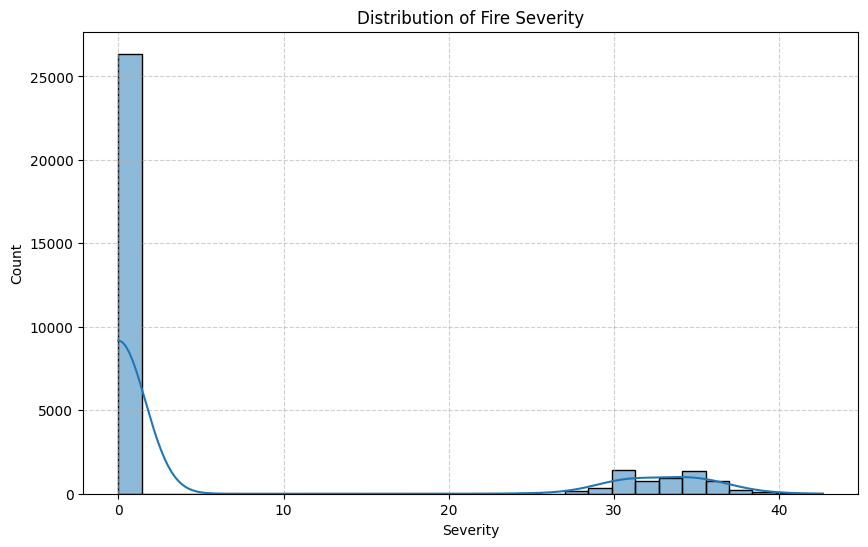

2025-07-28 02:56:24,999 - INFO - Distribution of 'Severity' target variable plotted.



--- Distributions of Numerical Features (Training Data) ---


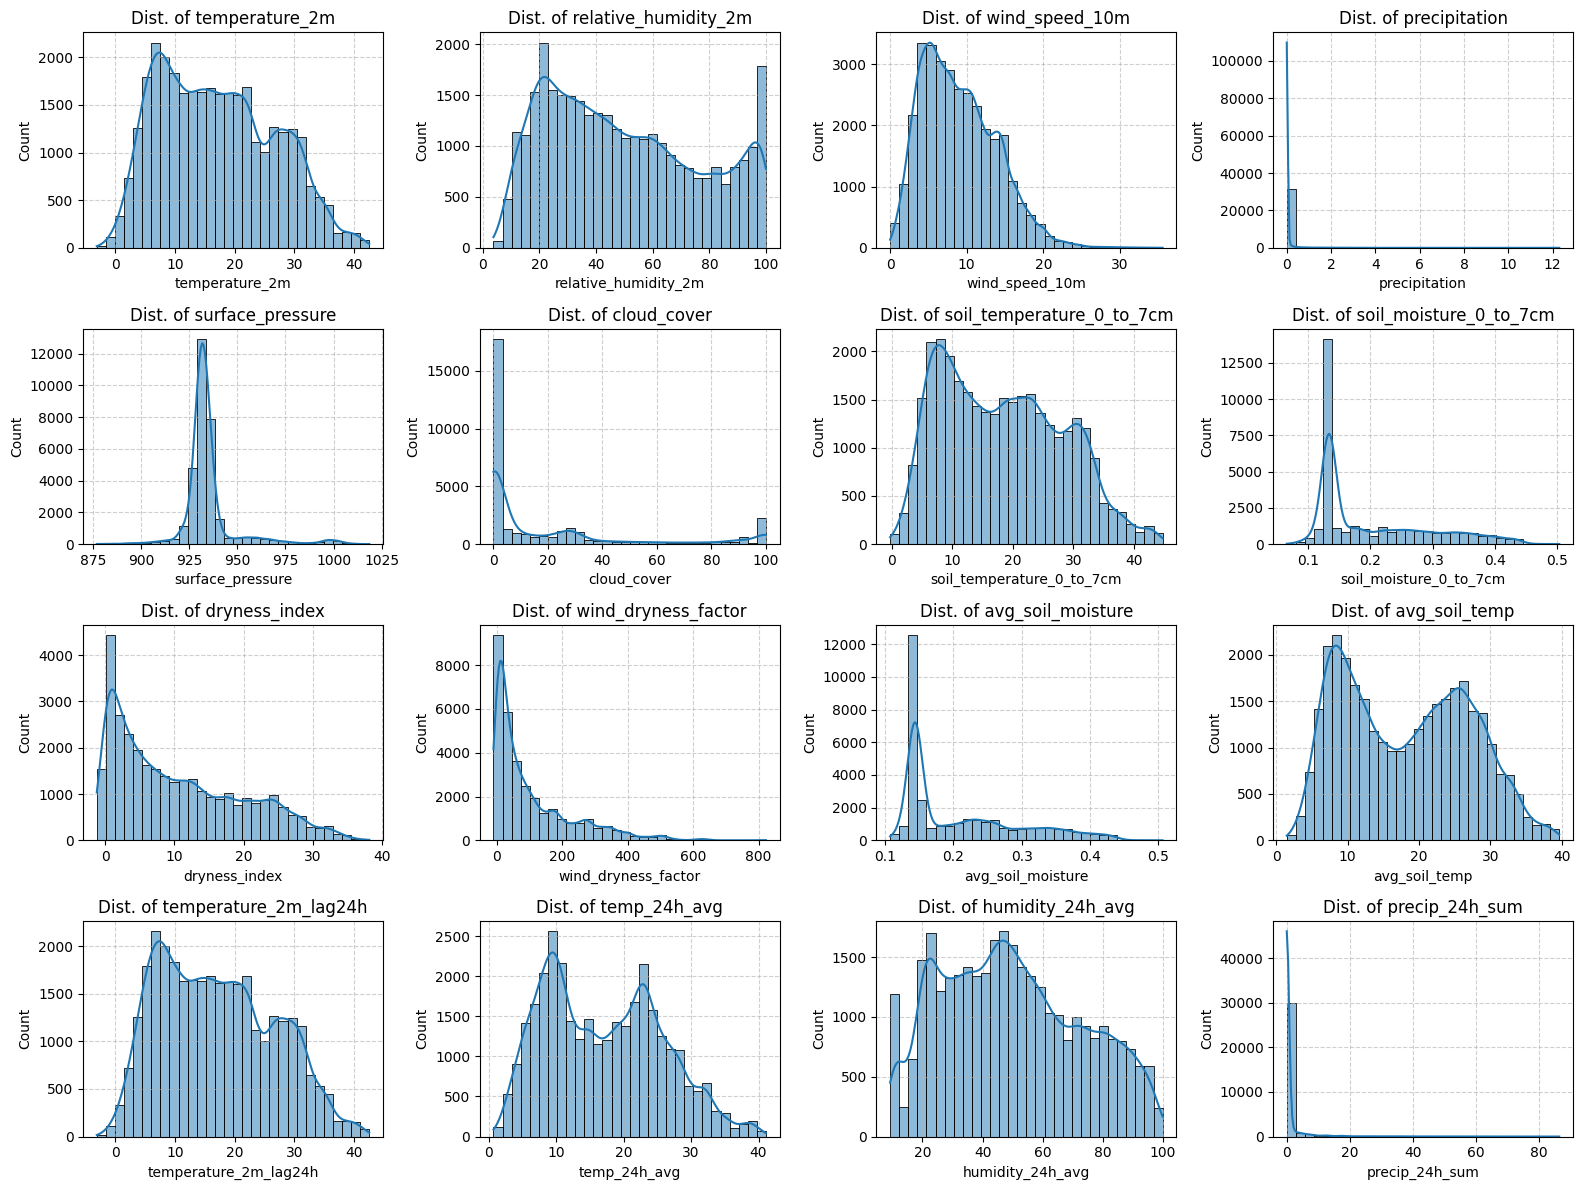

2025-07-28 02:56:35,127 - INFO - Distributions of 16 numerical features plotted.
2025-07-28 02:56:35,188 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:35,213 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



--- Distributions of Categorical Features (Training Data) ---


2025-07-28 02:56:35,367 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:35,394 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:35,498 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:35,532 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:35,680 - INFO - Using categorical units to plot a list of strings that are all parsable as 

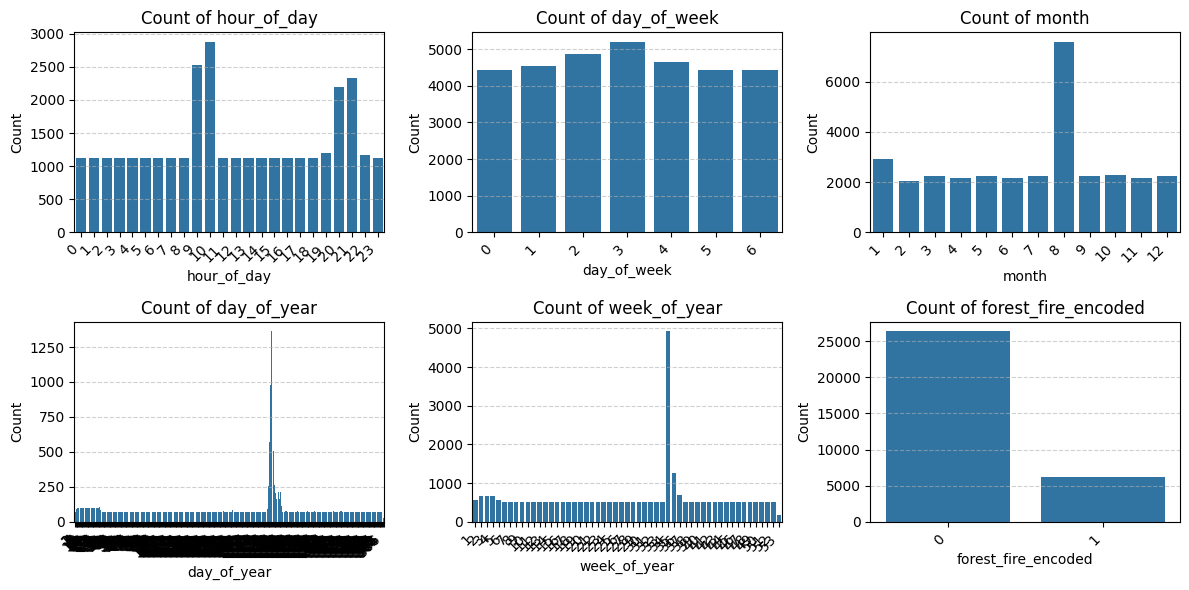

2025-07-28 02:56:41,766 - INFO - Distributions of 6 categorical features plotted.



--- Relationship between Severity and Selected Key Features (Scatter Plots) ---


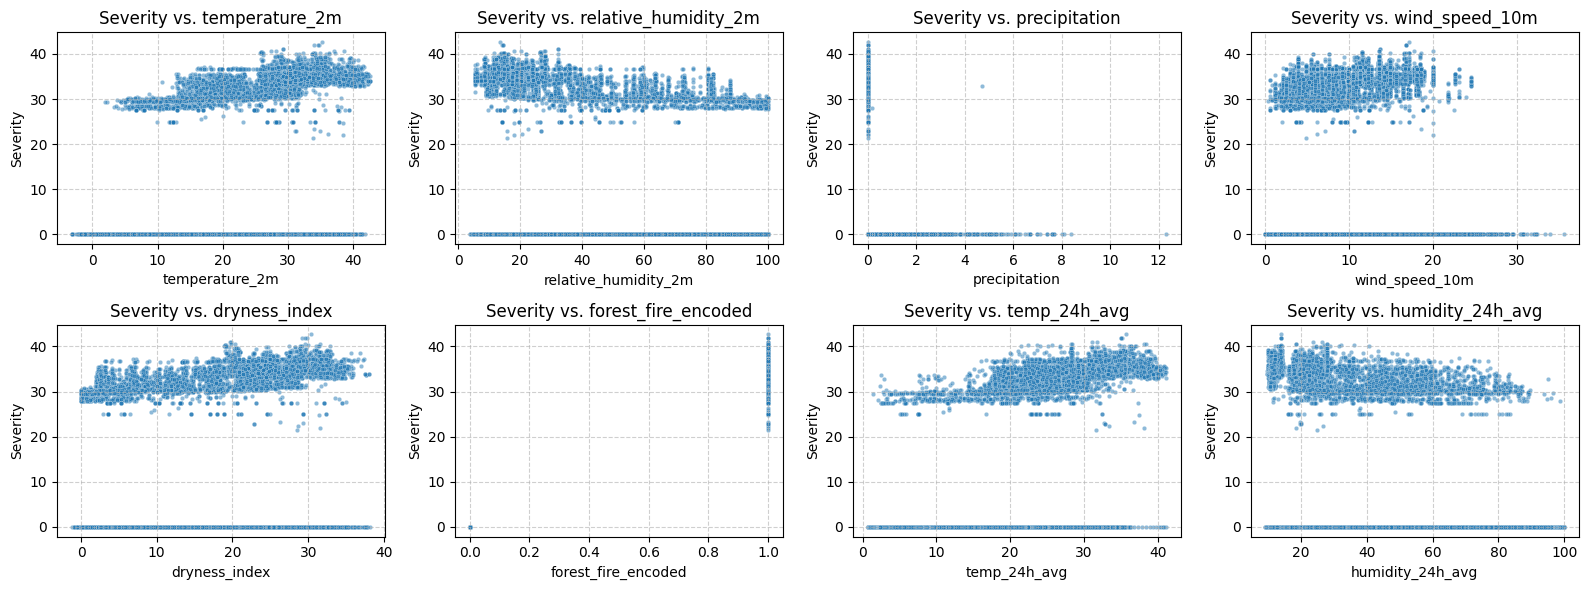

2025-07-28 02:56:44,740 - INFO - Scatter plots showing relationships between 'Severity' and 8 features.



Comprehensive descriptive statistics and distribution analysis complete.


In [28]:
# Cell 3: Comprehensive Descriptive Statistics and Distribution Analysis for Regression

import matplotlib.pyplot as plt
import seaborn as sns
import logging
import pandas as pd
import numpy as np # Ensure numpy is imported for np.number

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting comprehensive descriptive statistics and distribution analysis for regression...")

if 'y_reg_train' not in globals() or 'X_reg_train' not in globals():
    print("Training data for regression is not available. Please ensure Cell 2 ran successfully.")
else:
    # --- 1. Analyze the distribution of the target variable (Severity) ---
    print("\n--- Distribution of Target Variable: Severity (Training Data) ---")
    print(y_reg_train.describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(y_reg_train, kde=True, bins=30)
    plt.title('Distribution of Fire Severity')
    plt.xlabel('Severity')
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    logging.info("Distribution of 'Severity' target variable plotted.")

    # --- 2. Analyze distributions of all numerical features ---
    print("\n--- Distributions of Numerical Features (Training Data) ---")
    # Plotting all numerical features might be too many; select a representative sample or top N
    # For a truly non-biased initial look, we'll iterate through numerical_features_reg
    # We might limit to a reasonable number if there are hundreds.
    
    # Take a sample of numerical features to avoid overwhelming the output
    # For now, let's plot a few important ones and some new ones.
    features_for_detailed_hist = [
        'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation',
        'surface_pressure', 'cloud_cover',
        'soil_temperature_0_to_7cm', 'soil_moisture_0_to_7cm',
        'dryness_index', 'wind_dryness_factor', 'avg_soil_moisture', 'avg_soil_temp',
        'temperature_2m_lag24h', 'temp_24h_avg', 'humidity_24h_avg', 'precip_24h_sum'
    ]
    
    # Filter for features that actually exist in X_reg_train.columns
    existing_numeric_features = [f for f in features_for_detailed_hist if f in X_reg_train.columns]

    if existing_numeric_features:
        num_plots = len(existing_numeric_features)
        num_cols = 4
        num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed
        
        plt.figure(figsize=(num_cols * 4, num_rows * 3))
        for i, feature in enumerate(existing_numeric_features):
            plt.subplot(num_rows, num_cols, i + 1)
            sns.histplot(X_reg_train[feature], kde=True, bins=30)
            plt.title(f'Dist. of {feature}')
            plt.xlabel(feature)
            plt.ylabel('Count')
            plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        logging.info(f"Distributions of {len(existing_numeric_features)} numerical features plotted.")
    else:
        logging.warning("No numerical features found to plot distributions. Skipping this step.")

    # --- 3. Analyze distributions of categorical features (including encoded ones) ---
    print("\n--- Distributions of Categorical Features (Training Data) ---")
    # For 'forest_fire_encoded' and temporal categorical features
    
    features_for_detailed_bar = [
        'hour_of_day', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'forest_fire_encoded'
    ]

    # Filter for features that actually exist in X_reg_train.columns
    existing_categorical_features = [f for f in features_for_detailed_bar if f in X_reg_train.columns]

    if existing_categorical_features:
        num_plots = len(existing_categorical_features)
        num_cols = 3
        num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

        plt.figure(figsize=(num_cols * 4, num_rows * 3))
        for i, feature in enumerate(existing_categorical_features):
            plt.subplot(num_rows, num_cols, i + 1)
            sns.countplot(x=X_reg_train[feature])
            plt.title(f'Count of {feature}')
            plt.xlabel(feature)
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        logging.info(f"Distributions of {len(existing_categorical_features)} categorical features plotted.")
    else:
        logging.warning("No categorical features found to plot distributions. Skipping this step.")

    # --- 4. Explore relationships between Severity and a few key features (Scatter Plots) ---
    # Re-using a few key features that are likely to have a direct relationship with Severity
    key_relationship_features_scatter = [
        'temperature_2m', 'relative_humidity_2m', 'precipitation',
        'wind_speed_10m', 'dryness_index', 'forest_fire_encoded',
        'temp_24h_avg', 'humidity_24h_avg'
    ]
    
    # Filter for features that actually exist in X_reg_train.columns
    existing_rel_features_scatter = [f for f in key_relationship_features_scatter if f in X_reg_train.columns]

    if existing_rel_features_scatter:
        num_plots = len(existing_rel_features_scatter)
        num_cols = 4
        num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

        print("\n--- Relationship between Severity and Selected Key Features (Scatter Plots) ---")
        plt.figure(figsize=(num_cols * 4, num_rows * 3))
        for i, feature in enumerate(existing_rel_features_scatter):
            plt.subplot(num_rows, num_cols, i + 1)
            sns.scatterplot(x=X_reg_train[feature], y=y_reg_train, alpha=0.5, s=10)
            plt.title(f'Severity vs. {feature}')
            plt.xlabel(feature)
            plt.ylabel('Severity')
            plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        logging.info(f"Scatter plots showing relationships between 'Severity' and {len(existing_rel_features_scatter)} features.")
    else:
        logging.warning("No core features found to plot relationships with Severity. Skipping this step.")

print("\nComprehensive descriptive statistics and distribution analysis complete.")

Starting correlation analysis and advanced distribution plots for regression...

--- Correlation Matrix of Numerical Features (Training Data) ---


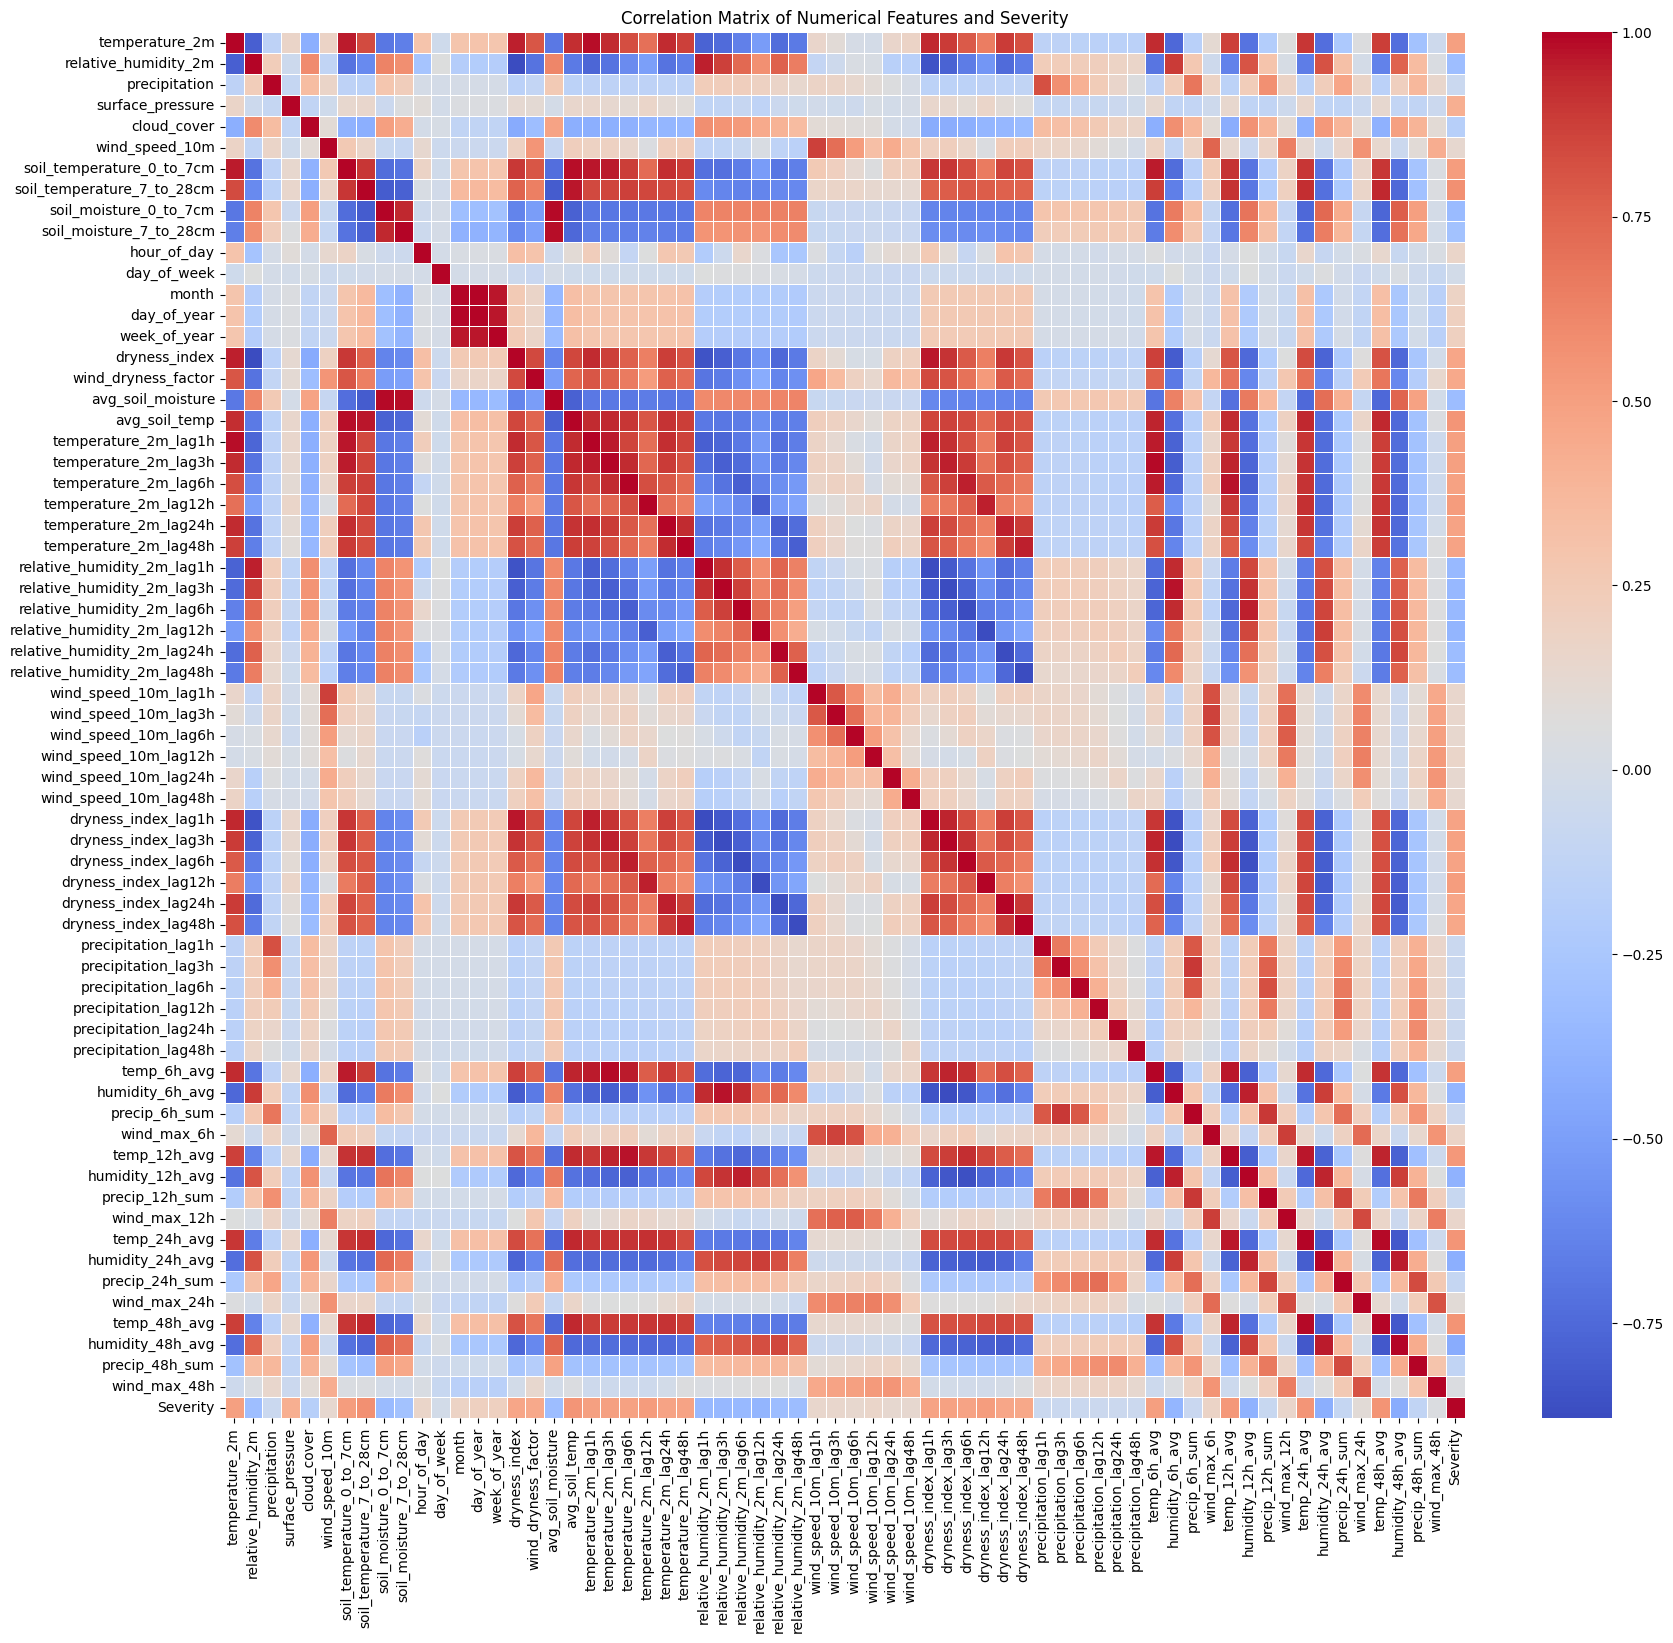

2025-07-28 02:56:50,593 - INFO - Correlation matrix of numerical features plotted.
C:\Users\Alok\AppData\Local\Temp\ipykernel_9688\1545997140.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=abs_severity_correlations.head(30).values, y=abs_severity_correlations.head(30).index, palette='viridis')



--- Top 20 Numerical Features Correlated with Severity (Absolute Value) ---
soil_temperature_7_to_28cm    0.567480
temp_48h_avg                  0.553243
temp_24h_avg                  0.550491
avg_soil_temp                 0.549870
temp_12h_avg                  0.531719
temperature_2m_lag12h         0.522718
dryness_index_lag12h          0.514403
soil_temperature_0_to_7cm     0.509333
temp_6h_avg                   0.505766
temperature_2m_lag1h          0.495977
temperature_2m_lag3h          0.495679
temperature_2m                0.494162
temperature_2m_lag6h          0.492130
dryness_index_lag3h           0.486606
dryness_index_lag1h           0.485912
temperature_2m_lag24h         0.485740
temperature_2m_lag48h         0.480232
dryness_index_lag6h           0.480038
dryness_index                 0.469632
dryness_index_lag24h          0.467724
Name: Severity, dtype: float64

--- Bottom 20 Numerical Features Correlated with Severity (Absolute Value) ---
precipitation_lag1h           -0

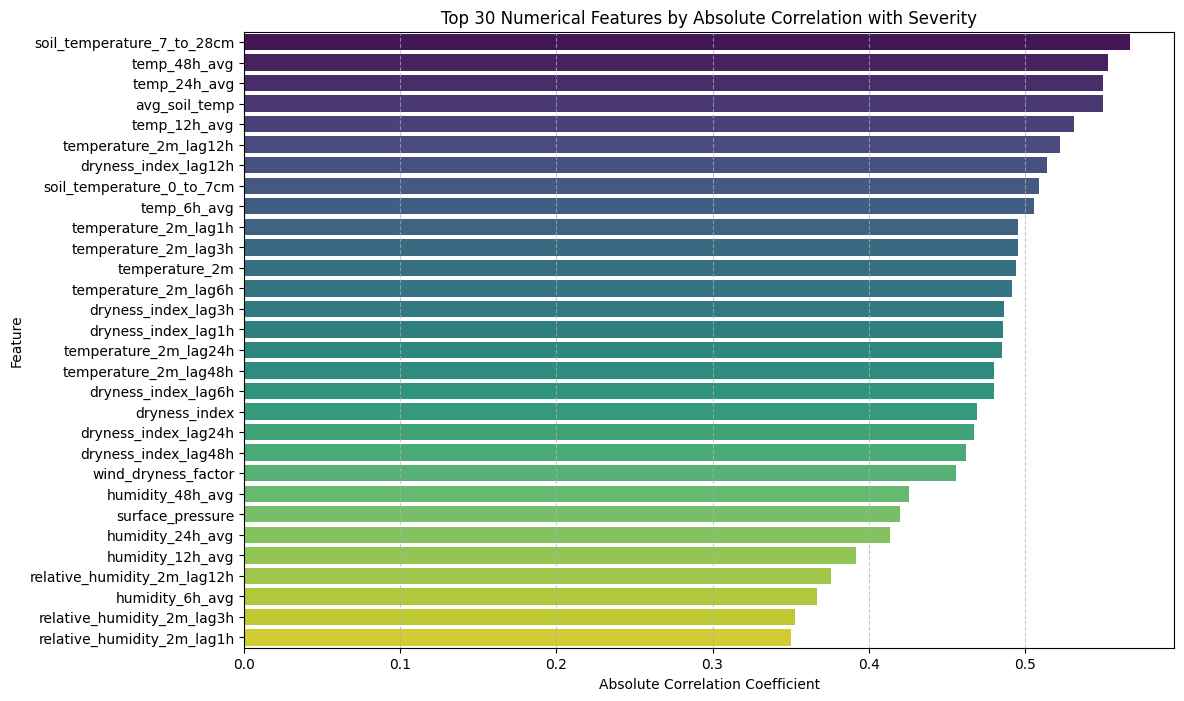

2025-07-28 02:56:51,622 - INFO - Bar plot of top numerical feature correlations with 'Severity' plotted.
2025-07-28 02:56:51,706 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:51,750 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



--- Box Plots: Categorical Features vs. Severity ---


2025-07-28 02:56:52,074 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:52,120 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:52,297 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:52,339 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-28 02:56:52,560 - INFO - Using categorical units to plot a list of strings that are all parsable as 

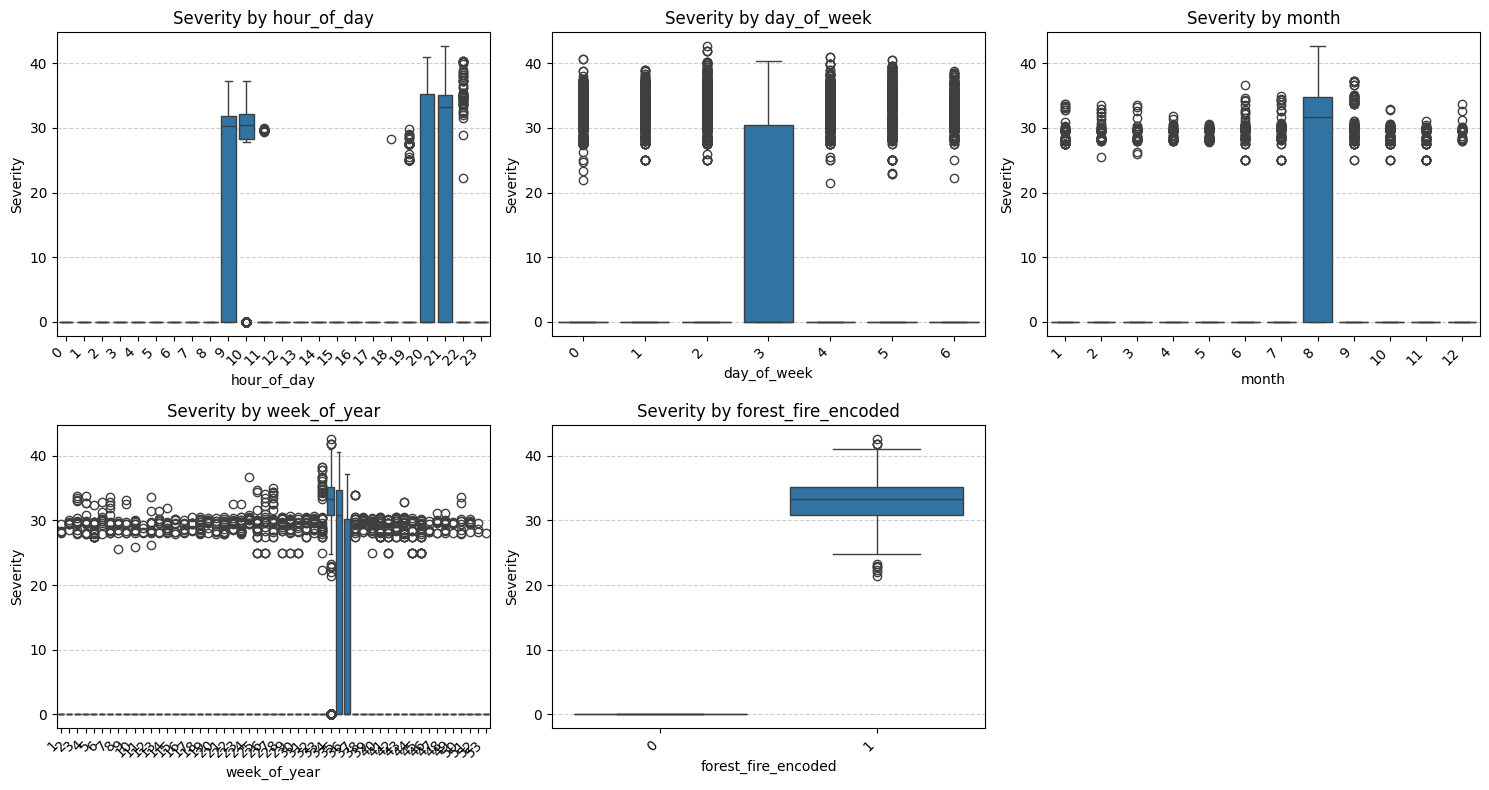

2025-07-28 02:56:54,613 - INFO - Box plots for 5 categorical features vs. 'Severity' plotted.



Correlation analysis and advanced distribution plots complete.


In [29]:
# Cell 4: Correlation Analysis and Advanced Distribution Plots for Regression

import matplotlib.pyplot as plt
import seaborn as sns
import logging
import pandas as pd
import numpy as np # Ensure numpy is imported for np.number

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting correlation analysis and advanced distribution plots for regression...")

if 'y_reg_train' not in globals() or 'X_reg_train' not in globals() or \
   'numerical_features_reg' not in globals() or 'categorical_features_reg' not in globals():
    print("Training data or feature lists are not available. Please ensure Cell 2 ran successfully.")
else:
    # Combine training features and target for correlation calculation
    # Only use numerical features for the heatmap for clarity
    df_train_combined_reg = pd.concat([X_reg_train[numerical_features_reg], y_reg_train], axis=1)

    # --- 1. Correlation Matrix (Heatmap) for Numerical Features ---
    print("\n--- Correlation Matrix of Numerical Features (Training Data) ---")
    plt.figure(figsize=(20, 18))
    # Select top 30 most correlated features for clarity in heatmap, if too many
    corr_matrix = df_train_combined_reg.corr()

    # If there are too many numerical features, consider plotting only correlations with target
    # or a subset of features. For now, let's plot all.
    # You might want to adjust the size or filter features if the plot is too dense.
    
    # Optional: Filter for features with high correlation to Severity
    # high_corr_features = corr_matrix['Severity'].abs().sort_values(ascending=False).head(30).index
    # corr_matrix_subset = df_train_combined_reg[high_corr_features].corr()
    
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numerical Features and Severity')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()
    logging.info("Correlation matrix of numerical features plotted.")

    # --- 2. Correlation of All Numerical Features with Target (Severity) ---
    print("\n--- Top 20 Numerical Features Correlated with Severity (Absolute Value) ---")
    severity_correlations = corr_matrix['Severity'].sort_values(ascending=False).drop('Severity') # Exclude self-correlation
    print(severity_correlations.head(20)) # Top 20 positive correlations
    print("\n--- Bottom 20 Numerical Features Correlated with Severity (Absolute Value) ---")
    print(severity_correlations.tail(20)) # Top 20 negative correlations

    plt.figure(figsize=(12, 8))
    # Plot absolute correlations for a cleaner view of strength
    abs_severity_correlations = severity_correlations.abs().sort_values(ascending=False)
    sns.barplot(x=abs_severity_correlations.head(30).values, y=abs_severity_correlations.head(30).index, palette='viridis')
    plt.title('Top 30 Numerical Features by Absolute Correlation with Severity')
    plt.xlabel('Absolute Correlation Coefficient')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    logging.info("Bar plot of top numerical feature correlations with 'Severity' plotted.")

    # --- 3. Box Plots for Categorical Features vs. Target (Severity) ---
    print("\n--- Box Plots: Categorical Features vs. Severity ---")
    
    # Select categorical features including the encoded 'forest_fire_encoded'
    # Ensure 'forest_fire_encoded' is treated as categorical for the plot
    features_for_box_plots = [
        'hour_of_day', 'day_of_week', 'month', 'week_of_year',
        'forest_fire_encoded' # Now that it's an integer 0/1, it's suitable for box plot x-axis
    ]

    # Filter for features that actually exist in X_reg_train.columns
    existing_box_plot_features = [f for f in features_for_box_plots if f in X_reg_train.columns]

    if existing_box_plot_features:
        num_plots = len(existing_box_plot_features)
        num_cols = 3
        num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

        plt.figure(figsize=(num_cols * 5, num_rows * 4))
        for i, feature in enumerate(existing_box_plot_features):
            plt.subplot(num_rows, num_cols, i + 1)
            sns.boxplot(x=X_reg_train[feature], y=y_reg_train)
            plt.title(f'Severity by {feature}')
            plt.xlabel(feature)
            plt.ylabel('Severity')
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        logging.info(f"Box plots for {len(existing_box_plot_features)} categorical features vs. 'Severity' plotted.")
    else:
        logging.warning("No categorical features suitable for box plots with Severity found. Skipping this step.")

    print("\nCorrelation analysis and advanced distribution plots complete.")

In [30]:
# Cell 6: Random Forest Regressor Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import logging
import numpy as np # Ensure numpy is imported for np.sqrt
import pandas as pd # For feature importance DataFrame

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting Random Forest Regressor model training and evaluation...")

if 'X_reg_train' not in globals() or 'y_reg_train' not in globals() or \
   'X_reg_test' not in globals() or 'y_reg_test' not in globals() or \
   'preprocessor_reg_global' not in globals():
    print("Required data or preprocessor not found. Please ensure Cell 2 ran successfully.")
else:
    # --- 1. Create a pipeline for Random Forest Regressor ---
    # Using a modest number of estimators for initial run. Hyperparameter tuning can optimize further.
    random_forest_reg_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_reg_global),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)) # n_jobs=-1 to use all cores
    ])
    logging.info("Random Forest Regressor pipeline created.")

    # --- 2. Train the model ---
    print("Training Random Forest Regressor model...")
    random_forest_reg_pipeline.fit(X_reg_train, y_reg_train)
    logging.info("Random Forest Regressor model trained.")

    # --- 3. Make predictions on the test set ---
    y_pred_rf = random_forest_reg_pipeline.predict(X_reg_test)
    logging.info("Predictions made on test set using Random Forest Regressor.")

    # Post-processing: Severity cannot be negative. Clip any negative predictions to 0.
    y_pred_rf[y_pred_rf < 0] = 0
    logging.info("Negative predictions from Random Forest Regressor clipped to 0.")

    # --- 4. Evaluate the model ---
    print("\n--- Random Forest Regressor Model Evaluation ---")
    r2_rf = r2_score(y_reg_test, y_pred_rf)
    mae_rf = mean_absolute_error(y_reg_test, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf))

    print(f"R-squared: {r2_rf:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
    logging.info(f"Random Forest Regressor evaluation: R2={r2_rf:.4f}, MAE={mae_rf:.4f}, RMSE={rmse_rf:.4f}")

    # --- 5. Analyze Feature Importance ---
    print("\n--- Random Forest Regressor Feature Importance (Top 20) ---")
    
    # Get feature names after one-hot encoding
    feature_names_out = random_forest_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = random_forest_reg_pipeline.named_steps['regressor'].feature_importances_
    
    feature_importance_rf = pd.DataFrame({'Feature': feature_names_out, 'Importance': importances})
    feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)
    
    print(feature_importance_rf.head(20))
    logging.info("Random Forest Regressor feature importances calculated.")

    # Store results for later comparison
    global rf_results # Make results global for final comparison
    rf_results = {'model': 'Random Forest Regressor', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf}
    logging.info("Random Forest Regressor results stored.")

print("\nRandom Forest Regressor model training and evaluation complete.")

2025-07-28 02:56:59,092 - INFO - Random Forest Regressor pipeline created.


Starting Random Forest Regressor model training and evaluation...
Training Random Forest Regressor model...


2025-07-28 02:57:37,220 - INFO - Random Forest Regressor model trained.
2025-07-28 02:57:37,296 - INFO - Predictions made on test set using Random Forest Regressor.
2025-07-28 02:57:37,297 - INFO - Negative predictions from Random Forest Regressor clipped to 0.
2025-07-28 02:57:37,300 - INFO - Random Forest Regressor evaluation: R2=0.9972, MAE=0.0344, RMSE=0.2528
2025-07-28 02:57:37,347 - INFO - Random Forest Regressor feature importances calculated.
2025-07-28 02:57:37,348 - INFO - Random Forest Regressor results stored.



--- Random Forest Regressor Model Evaluation ---
R-squared: 0.9972
Mean Absolute Error (MAE): 0.0344
Root Mean Squared Error (RMSE): 0.2528

--- Random Forest Regressor Feature Importance (Top 20) ---
                             Feature  Importance
65        cat__forest_fire_encoded_0    0.505763
66        cat__forest_fire_encoded_1    0.485931
10                  num__hour_of_day    0.003688
17            num__avg_soil_moisture    0.000555
9       num__soil_moisture_7_to_28cm    0.000414
54             num__humidity_12h_avg    0.000227
58             num__humidity_24h_avg    0.000210
8        num__soil_moisture_0_to_7cm    0.000200
3              num__surface_pressure    0.000166
16          num__wind_dryness_factor    0.000138
1          num__relative_humidity_2m    0.000113
0                num__temperature_2m    0.000097
61                 num__temp_48h_avg    0.000096
50              num__humidity_6h_avg    0.000087
26   num__relative_humidity_2m_lag3h    0.000083
53            

In [31]:
# Cell 7: XGBoost Regressor Model

import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import logging
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting XGBoost Regressor model training and evaluation...")

if 'X_reg_train' not in globals() or 'y_reg_train' not in globals() or \
   'X_reg_test' not in globals() or 'y_reg_test' not in globals() or \
   'preprocessor_reg_global' not in globals():
    print("Required data or preprocessor not found. Please ensure Cell 2 ran successfully.")
else:
    # --- 1. Create a pipeline for XGBoost Regressor ---
    # XGBoost can accept processed NumPy arrays directly.
    # It's generally good practice to apply preprocessing before feeding to XGBoost's DMatrix.
    
    # Preprocess training and test data for XGBoost
    X_reg_train_processed = preprocessor_reg_global.fit_transform(X_reg_train)
    X_reg_test_processed = preprocessor_reg_global.transform(X_reg_test)
    logging.info("Data preprocessed for XGBoost Regressor.")

    # Convert to DMatrix for optimized XGBoost training
    dtrain_reg = xgb.DMatrix(X_reg_train_processed, label=y_reg_train)
    dtest_reg = xgb.DMatrix(X_reg_test_processed, label=y_reg_test)
    logging.info("Data converted to DMatrix format for XGBoost Regressor.")

    # --- 2. Set XGBoost parameters for regression ---
    # 'objective': 'reg:squarederror' for standard regression
    # 'eval_metric': 'rmse' for evaluation during training
    # Parameters like max_depth, eta (learning rate), subsample, colsample_bytree for regularization
    
    xgb_reg_params = {
        'objective': 'reg:squarederror', # Objective for regression
        'eval_metric': 'rmse',           # Evaluation metric
        'eta': 0.05,                     # Learning rate
        'max_depth': 6,                  # Maximum depth of a tree
        'subsample': 0.8,                # Subsample ratio of the training instance
        'colsample_bytree': 0.8,         # Subsample ratio of columns when constructing each tree
        'lambda': 1,                     # L2 regularization term on weights
        'alpha': 0,                      # L1 regularization term on weights
        'seed': 42,                      # Random seed for reproducibility
        'nthread': -1,                   # Use all available threads
        'tree_method': 'hist'            # Faster for larger datasets, 'gpu_hist' for GPU
    }
    logging.info("XGBoost Regressor parameters set.")

    # --- 3. Train the model ---
    print("Training XGBoost Regressor model...")
    xgb_reg_model = xgb.train(xgb_reg_params,
                              dtrain_reg,
                              num_boost_round=1000,          # Number of boosting rounds
                              evals=[(dtest_reg, 'validation')], # Evaluation set
                              early_stopping_rounds=100,     # Stop if validation metric doesn't improve
                              verbose_eval=False)            # Set to True for verbose output
    
    logging.info(f"XGBoost Regressor model trained. Best iteration: {xgb_reg_model.best_iteration}")

    # --- 4. Make predictions on the test set ---
    y_pred_xgb_reg = xgb_reg_model.predict(dtest_reg, iteration_range=(0, xgb_reg_model.best_iteration))
    logging.info("Predictions made on test set using XGBoost Regressor.")

    # Post-processing: Severity cannot be negative. Clip any negative predictions to 0.
    y_pred_xgb_reg[y_pred_xgb_reg < 0] = 0
    logging.info("Negative predictions from XGBoost Regressor clipped to 0.")

    # --- 5. Evaluate the model ---
    print("\n--- XGBoost Regressor Model Evaluation ---")
    r2_xgb_reg = r2_score(y_reg_test, y_pred_xgb_reg)
    mae_xgb_reg = mean_absolute_error(y_reg_test, y_pred_xgb_reg)
    rmse_xgb_reg = np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb_reg))

    print(f"R-squared: {r2_xgb_reg:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_xgb_reg:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_xgb_reg:.4f}")
    logging.info(f"XGBoost Regressor evaluation: R2={r2_xgb_reg:.4f}, MAE={mae_xgb_reg:.4f}, RMSE={rmse_xgb_reg:.4f}")

    # --- 6. Analyze Feature Importance ---
    print("\n--- XGBoost Regressor Feature Importance (Top 20) ---")
    
    feature_names_out = preprocessor_reg_global.get_feature_names_out()
    importances = xgb_reg_model.get_score(importance_type='gain') # 'gain' is often preferred for regression
    
    # Map internal feature names (f0, f1, ...) to actual feature names
    feature_importance_xgb_reg = pd.DataFrame(importances.items(), columns=['Feature_Index', 'Importance'])
    try:
        feature_importance_xgb_reg['Feature'] = feature_importance_xgb_reg['Feature_Index'].astype(str).str.replace('f', '').astype(int).map(lambda x: feature_names_out[x] if x < len(feature_names_out) else f'Unknown_f{x}')
        feature_importance_xgb_reg = feature_importance_xgb_reg.sort_values(by='Importance', ascending=False)
        print(feature_importance_xgb_reg.head(20))
    except Exception as e:
        logging.warning(f"Could not reliably map XGBoost feature importances to original names: {e}. Displaying raw feature indices and importance scores.")
        print(feature_importance_xgb_reg.sort_values(by='Importance', ascending=False).head(20))

    logging.info("XGBoost Regressor feature importances calculated.")

    # Store results for later comparison
    global xgb_reg_results # Make results global for final comparison
    xgb_reg_results = {'model': 'XGBoost Regressor', 'R2': r2_xgb_reg, 'MAE': mae_xgb_reg, 'RMSE': rmse_xgb_reg}
    logging.info("XGBoost Regressor results stored.")

print("\nXGBoost Regressor model training and evaluation complete.")

2025-07-28 02:57:43,248 - INFO - Data preprocessed for XGBoost Regressor.


Starting XGBoost Regressor model training and evaluation...


2025-07-28 02:57:44,983 - INFO - Data converted to DMatrix format for XGBoost Regressor.
2025-07-28 02:57:44,984 - INFO - XGBoost Regressor parameters set.


Training XGBoost Regressor model...


2025-07-28 02:57:49,006 - INFO - XGBoost Regressor model trained. Best iteration: 123
2025-07-28 02:57:49,014 - INFO - Predictions made on test set using XGBoost Regressor.
2025-07-28 02:57:49,016 - INFO - Negative predictions from XGBoost Regressor clipped to 0.
2025-07-28 02:57:49,021 - INFO - XGBoost Regressor evaluation: R2=0.9201, MAE=0.7302, RMSE=1.3561
2025-07-28 02:57:49,034 - INFO - XGBoost Regressor feature importances calculated.
2025-07-28 02:57:49,037 - INFO - XGBoost Regressor results stored.



--- XGBoost Regressor Model Evaluation ---
R-squared: 0.9201
Mean Absolute Error (MAE): 0.7302
Root Mean Squared Error (RMSE): 1.3561

--- XGBoost Regressor Feature Importance (Top 20) ---
   Feature_Index     Importance                          Feature
59           f65  286980.500000       cat__forest_fire_encoded_0
60           f66  120871.179688       cat__forest_fire_encoded_1
3             f3    4450.190430            num__surface_pressure
17           f17    4065.571533           num__avg_soil_moisture
12           f12    1174.377075                       num__month
10           f10     844.346863                 num__hour_of_day
7             f7     731.976746  num__soil_temperature_7_to_28cm
52           f57     685.095703                num__temp_24h_avg
56           f62     498.196320            num__humidity_48h_avg
14           f14     408.471588                num__week_of_year
9             f9     379.125641     num__soil_moisture_7_to_28cm
46           f49     208.62854

In [32]:
# Cell 8: LightGBM Regressor Model (No Changes, previous logging fix applied)

import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import logging
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting LightGBM Regressor model training and evaluation...")

if 'X_reg_train' not in globals() or 'y_reg_train' not in globals() or \
   'X_reg_test' not in globals() or 'y_reg_test' not in globals() or \
   'preprocessor_reg_global' not in globals():
    print("Required data or preprocessor not found. Please ensure Cell 2 ran successfully.")
else:
    # --- 1. Create a pipeline for LightGBM Regressor ---
    X_reg_train_processed = preprocessor_reg_global.fit_transform(X_reg_train)
    X_reg_test_processed = preprocessor_reg_global.transform(X_reg_test)
    logging.info("Data preprocessed for LightGBM Regressor.")

    feature_names_lgbm = preprocessor_reg_global.get_feature_names_out().tolist()

    # --- 2. Initialize LightGBM Regressor with parameters ---
    lgbm_reg_model = lgb.LGBMRegressor(objective='regression_l1',
                                     metric='rmse',
                                     n_estimators=1000,
                                     learning_rate=0.05,
                                     num_leaves=31,
                                     max_depth=-1,
                                     min_child_samples=20,
                                     subsample=0.8,
                                     colsample_bytree=0.8,
                                     reg_alpha=0,
                                     reg_lambda=1,
                                     random_state=42,
                                     n_jobs=-1,
                                     verbose=-1)
    logging.info("LightGBM Regressor model initialized.")

    # --- 3. Train the model ---
    print("Training LightGBM Regressor model...")
    lgbm_reg_model.fit(X_reg_train_processed, y_reg_train,
                        eval_set=[(X_reg_test_processed, y_reg_test)],
                        eval_metric='rmse',
                        callbacks=[lgb.early_stopping(100, verbose=False)],
                        feature_name=feature_names_lgbm)

    logging.info(f"LightGBM Regressor model trained. Best iteration: {lgbm_reg_model.best_iteration_}")

    # --- 4. Make predictions on the test set ---
    global y_pred_lgbm_reg
    y_pred_lgbm_reg = lgbm_reg_model.predict(X_reg_test_processed, num_iteration=lgbm_reg_model.best_iteration_)
    logging.info("Predictions made on test set using LightGBM Regressor.")

    # Post-processing: Severity cannot be negative. Clip any negative predictions to 0.
    y_pred_lgbm_reg[y_pred_lgbm_reg < 0] = 0
    logging.info("Negative predictions from LightGBM Regressor clipped to 0.")

    # --- 5. Evaluate the model ---
    print("\n--- LightGBM Regressor Model Evaluation ---")
    r2_lgbm_reg = r2_score(y_reg_test, y_pred_lgbm_reg)
    mae_lgbm_reg = mean_absolute_error(y_reg_test, y_pred_lgbm_reg)
    rmse_lgbm_reg = np.sqrt(mean_squared_error(y_reg_test, y_pred_lgbm_reg))

    print(f"R-squared: {r2_lgbm_reg:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_lgbm_reg:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_lgbm_reg:.4f}")
    logging.info(f"LightGBM Regressor evaluation: R2={r2_lgbm_reg:.4f}, MAE={mae_lgbm_reg:.4f}, RMSE={rmse_lgbm_reg:.4f}")

    # --- 6. Analyze Feature Importance ---
    print("\n--- LightGBM Regressor Feature Importance (Top 20) ---")
    
    importances_lgbm = lgbm_reg_model.feature_importances_
    
    feature_importance_lgbm_reg = pd.DataFrame({'Feature': feature_names_lgbm, 'Importance': importances_lgbm})
    feature_importance_lgbm_reg = feature_importance_lgbm_reg.sort_values(by='Importance', ascending=False)
    
    print(feature_importance_lgbm_reg.head(20))
    logging.info("LightGBM Regressor feature importances calculated.")

    global lgbm_reg_results
    lgbm_reg_results = {'model': 'LightGBM Regressor', 'R2': r2_lgbm_reg, 'MAE': mae_lgbm_reg, 'RMSE': rmse_lgbm_reg}
    logging.info("LightGBM Regressor results stored.")

print("\nLightGBM Regressor model training and evaluation complete.")

2025-07-28 02:57:52,662 - INFO - Data preprocessed for LightGBM Regressor.
2025-07-28 02:57:52,666 - INFO - LightGBM Regressor model initialized.


Starting LightGBM Regressor model training and evaluation...
Training LightGBM Regressor model...


2025-07-28 02:57:54,198 - INFO - LightGBM Regressor model trained. Best iteration: 60
2025-07-28 02:57:54,212 - INFO - Predictions made on test set using LightGBM Regressor.
2025-07-28 02:57:54,214 - INFO - Negative predictions from LightGBM Regressor clipped to 0.
2025-07-28 02:57:54,218 - INFO - LightGBM Regressor evaluation: R2=0.9972, MAE=0.0719, RMSE=0.2534
2025-07-28 02:57:54,229 - INFO - LightGBM Regressor feature importances calculated.
2025-07-28 02:57:54,231 - INFO - LightGBM Regressor results stored.



--- LightGBM Regressor Model Evaluation ---
R-squared: 0.9972
Mean Absolute Error (MAE): 0.0719
Root Mean Squared Error (RMSE): 0.2534

--- LightGBM Regressor Feature Importance (Top 20) ---
                             Feature  Importance
65        cat__forest_fire_encoded_0          53
3              num__surface_pressure          49
10                  num__hour_of_day          41
8        num__soil_moisture_0_to_7cm          34
13                  num__day_of_year          32
40         num__dryness_index_lag12h          30
7    num__soil_temperature_7_to_28cm          29
9       num__soil_moisture_7_to_28cm          22
53                 num__temp_12h_avg          20
22        num__temperature_2m_lag12h          19
62             num__humidity_48h_avg          18
17            num__avg_soil_moisture          18
1          num__relative_humidity_2m          15
0                num__temperature_2m          14
16          num__wind_dryness_factor          13
24        num__temperatu

2025-07-28 02:58:02,051 - INFO - Random Forest Regressor Non-Zero Evaluation: R2=0.3278, MAE=1.1150, RMSE=1.4392
2025-07-28 02:58:02,057 - INFO - XGBoost Regressor Non-Zero Evaluation: R2=0.3267, MAE=1.0852, RMSE=1.4404
2025-07-28 02:58:02,060 - INFO - LightGBM Regressor Non-Zero Evaluation: R2=0.4088, MAE=1.0308, RMSE=1.3497


Starting deeper performance analysis and visualization for trained models...

--- Performance Evaluation on Non-Zero Severity Values (Actuals > 0) ---

--- Random Forest Regressor (Non-Zero Severity) ---
R-squared (Non-Zero): 0.3278
MAE (Non-Zero): 1.1150
RMSE (Non-Zero): 1.4392

--- XGBoost Regressor (Non-Zero Severity) ---
R-squared (Non-Zero): 0.3267
MAE (Non-Zero): 1.0852
RMSE (Non-Zero): 1.4404

--- LightGBM Regressor (Non-Zero Severity) ---
R-squared (Non-Zero): 0.4088
MAE (Non-Zero): 1.0308
RMSE (Non-Zero): 1.3497

--- Visualization: Predictions vs. Actuals (Focus on Higher Severity) ---


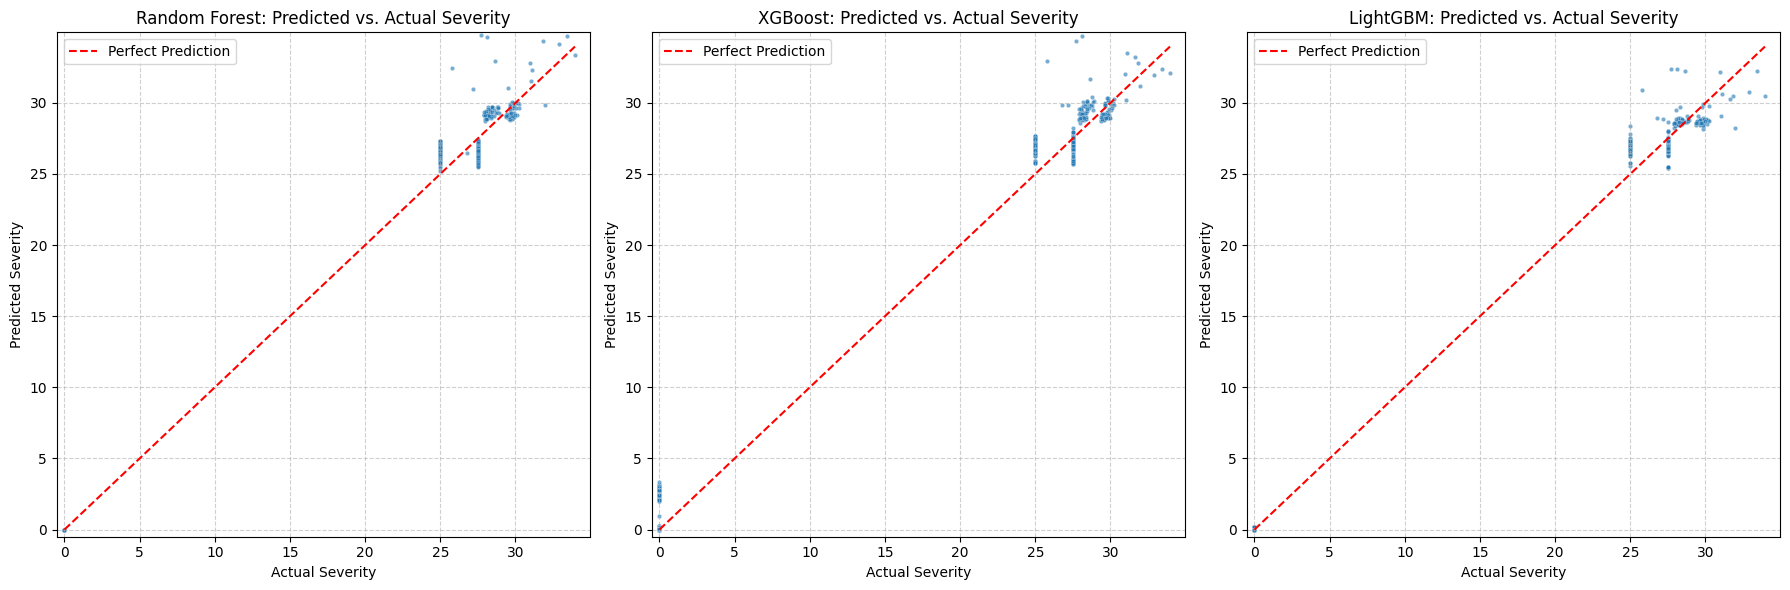

2025-07-28 02:58:03,819 - INFO - Scatter plots for Predicted vs. Actual Severity generated.


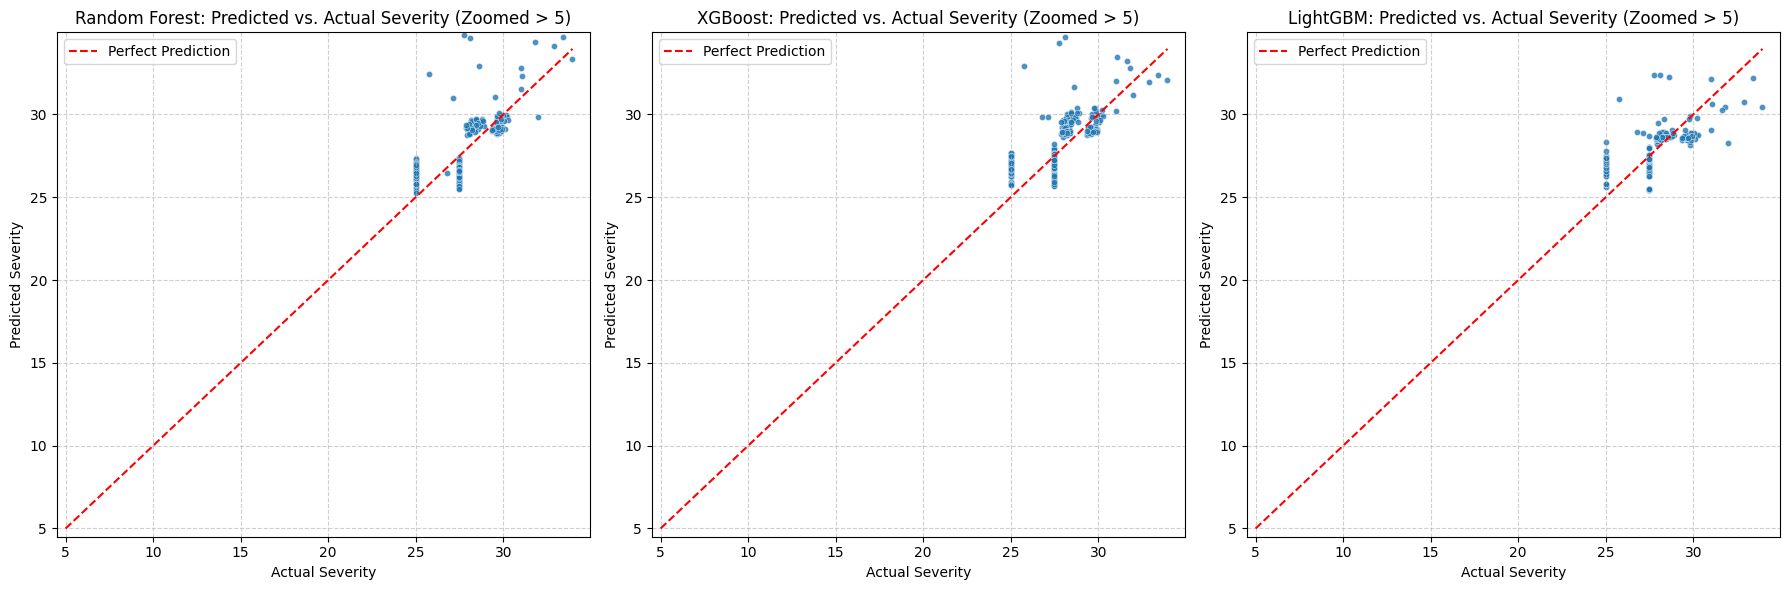

2025-07-28 02:58:04,617 - INFO - Zoomed scatter plots for Predicted vs. Actual Severity (actuals >= 5) generated.



Deeper performance analysis and visualization complete.


In [33]:
# Cell 9: Deeper Performance Analysis and Visualization (No Changes)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("Starting deeper performance analysis and visualization for trained models...")

# Ensure all necessary variables are available globally
required_vars = ['y_reg_test', 'y_pred_rf', 'y_pred_xgb_reg', 'y_pred_lgbm_reg']
if not all(var in globals() for var in required_vars):
    print("One or more required model prediction variables are not available. Please ensure Cells 6, 7, and 8 ran successfully.")
else:
    # --- 1. Evaluate metrics only on non-zero Severity values ---
    print("\n--- Performance Evaluation on Non-Zero Severity Values (Actuals > 0) ---")

    # Create a mask for non-zero actual severity values
    non_zero_mask = y_reg_test > 0
    y_test_non_zero = y_reg_test[non_zero_mask]

    if len(y_test_non_zero) == 0:
        print("No non-zero severity values found in the test set. Cannot perform this analysis.")
        logging.warning("No non-zero severity values found in test set for specific analysis.")
    else:
        models_and_preds = {
            "Random Forest Regressor": y_pred_rf,
            "XGBoost Regressor": y_pred_xgb_reg,
            "LightGBM Regressor": y_pred_lgbm_reg
        }

        for model_name, y_pred in models_and_preds.items():
            y_pred_non_zero = y_pred[non_zero_mask]

            # Recalculate metrics for non-zero subset
            r2_non_zero = r2_score(y_test_non_zero, y_pred_non_zero)
            mae_non_zero = mean_absolute_error(y_test_non_zero, y_pred_non_zero)
            rmse_non_zero = np.sqrt(mean_squared_error(y_test_non_zero, y_pred_non_zero))

            print(f"\n--- {model_name} (Non-Zero Severity) ---")
            print(f"R-squared (Non-Zero): {r2_non_zero:.4f}")
            print(f"MAE (Non-Zero): {mae_non_zero:.4f}")
            print(f"RMSE (Non-Zero): {rmse_non_zero:.4f}")
            logging.info(f"{model_name} Non-Zero Evaluation: R2={r2_non_zero:.4f}, MAE={mae_non_zero:.4f}, RMSE={rmse_non_zero:.4f}")

    # --- 2. Visualize predictions vs. actuals, focusing on higher severity values ---
    print("\n--- Visualization: Predictions vs. Actuals (Focus on Higher Severity) ---")

    # Combine actuals and predictions into a DataFrame for easier plotting
    plot_df = pd.DataFrame({
        'Actual Severity': y_reg_test,
        'RF Predicted Severity': y_pred_rf,
        'XGB Predicted Severity': y_pred_xgb_reg,
        'LGBM Predicted Severity': y_pred_lgbm_reg
    })

    max_severity = y_reg_test.max()

    plt.figure(figsize=(18, 6))

    # Scatter plot for Random Forest
    plt.subplot(1, 3, 1)
    sns.scatterplot(x='Actual Severity', y='RF Predicted Severity', data=plot_df, alpha=0.6, s=10)
    plt.plot([0, max_severity], [0, max_severity], color='red', linestyle='--', label='Perfect Prediction') # y=x line
    plt.title('Random Forest: Predicted vs. Actual Severity')
    plt.xlabel('Actual Severity')
    plt.ylabel('Predicted Severity')
    plt.xlim(-0.5, max_severity + 1)
    plt.ylim(-0.5, max_severity + 1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Scatter plot for XGBoost
    plt.subplot(1, 3, 2)
    sns.scatterplot(x='Actual Severity', y='XGB Predicted Severity', data=plot_df, alpha=0.6, s=10)
    plt.plot([0, max_severity], [0, max_severity], color='red', linestyle='--', label='Perfect Prediction')
    plt.title('XGBoost: Predicted vs. Actual Severity')
    plt.xlabel('Actual Severity')
    plt.ylabel('Predicted Severity')
    plt.xlim(-0.5, max_severity + 1)
    plt.ylim(-0.5, max_severity + 1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Scatter plot for LightGBM
    plt.subplot(1, 3, 3)
    sns.scatterplot(x='Actual Severity', y='LGBM Predicted Severity', data=plot_df, alpha=0.6, s=10)
    plt.plot([0, max_severity], [0, max_severity], color='red', linestyle='--', label='Perfect Prediction')
    plt.title('LightGBM: Predicted vs. Actual Severity')
    plt.xlabel('Actual Severity')
    plt.ylabel('Predicted Severity')
    plt.xlim(-0.5, max_severity + 1)
    plt.ylim(-0.5, max_severity + 1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()
    logging.info("Scatter plots for Predicted vs. Actual Severity generated.")

    # Second set of plots: Zoomed-in view for higher severity values
    zoom_min_severity = 5 # Example: focus on severity values 5 and above for detailed view
    
    plot_df_zoom = plot_df[plot_df['Actual Severity'] >= zoom_min_severity]
    
    if len(plot_df_zoom) > 0:
        plt.figure(figsize=(18, 6))

        # Scatter plot for Random Forest (Zoomed)
        plt.subplot(1, 3, 1)
        sns.scatterplot(x='Actual Severity', y='RF Predicted Severity', data=plot_df_zoom, alpha=0.8, s=20)
        plt.plot([zoom_min_severity, max_severity], [zoom_min_severity, max_severity], color='red', linestyle='--', label='Perfect Prediction')
        plt.title(f'Random Forest: Predicted vs. Actual Severity (Zoomed > {zoom_min_severity})')
        plt.xlabel('Actual Severity')
        plt.ylabel('Predicted Severity')
        plt.xlim(zoom_min_severity - 0.5, max_severity + 1)
        plt.ylim(zoom_min_severity - 0.5, max_severity + 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # Scatter plot for XGBoost (Zoomed)
        plt.subplot(1, 3, 2)
        sns.scatterplot(x='Actual Severity', y='XGB Predicted Severity', data=plot_df_zoom, alpha=0.8, s=20)
        plt.plot([zoom_min_severity, max_severity], [zoom_min_severity, max_severity], color='red', linestyle='--', label='Perfect Prediction')
        plt.title(f'XGBoost: Predicted vs. Actual Severity (Zoomed > {zoom_min_severity})')
        plt.xlabel('Actual Severity')
        plt.ylabel('Predicted Severity')
        plt.xlim(zoom_min_severity - 0.5, max_severity + 1)
        plt.ylim(zoom_min_severity - 0.5, max_severity + 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # Scatter plot for LightGBM (Zoomed)
        plt.subplot(1, 3, 3)
        sns.scatterplot(x='Actual Severity', y='LGBM Predicted Severity', data=plot_df_zoom, alpha=0.8, s=20)
        plt.plot([zoom_min_severity, max_severity], [zoom_min_severity, max_severity], color='red', linestyle='--', label='Perfect Prediction')
        plt.title(f'LightGBM: Predicted vs. Actual Severity (Zoomed > {zoom_min_severity})')
        plt.xlabel('Actual Severity')
        plt.ylabel('Predicted Severity')
        plt.xlim(zoom_min_severity - 0.5, max_severity + 1)
        plt.ylim(zoom_min_severity - 0.5, max_severity + 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        plt.tight_layout()
        plt.show()
        logging.info(f"Zoomed scatter plots for Predicted vs. Actual Severity (actuals >= {zoom_min_severity}) generated.")
    else:
        print(f"No actual severity values >= {zoom_min_severity} in the test set to generate zoomed plots.")
        logging.info("Not enough high severity values for zoomed plots.")

print("\nDeeper performance analysis and visualization complete.")

While Random Forest, XGBoost, and LightGBM are excellent choices for regression, especially with tabular data and their robustness to skewed distributions, as a "devil's advocate," it's crucial to consider alternative models that might theoretically be better suited for the unique characteristics of our Severity target variable.

Devil's Advocate: Alternative Regression Models for Wildfire Severity

The most significant characteristic of our Severity target is its zero-inflated nature: a large number of instances have a severity of 0 (no fire or negligible impact), while other instances have varying positive severity values. This directly reflects the real-world fact that wildfires are rare events. Standard regression models, even powerful ensemble ones, primarily aim to predict the mean of the target variable and may struggle with this dual nature.

Here are other model types that could be considered:

Zero-Inflated Regression Models (e.g., Zero-Inflated Poisson, Zero-Inflated Negative Binomial):

Concept: These models are specifically designed for data with an excess of zero outcomes. They typically consist of two parts:

A binary classification model (e.g., logistic regression) that predicts whether the outcome is zero or non-zero (i.e., whether a fire of any severity occurs).

A conditional regression model (e.g., Poisson or Negative Binomial) that predicts the magnitude of the outcome given that it is non-zero.

Pros: This approach directly addresses the "fires don't always happen" practical scenario by separately modeling the occurrence and the intensity. It can lead to more accurate predictions for both the probability of a fire and its actual severity when it does occur.

Cons: More complex to implement, train, and interpret than a single-stage regression model. Often requires specialized statistical packages (like statsmodels in Python) rather than being part of scikit-learn's standard suite.

Quantile Regression:

Concept: Instead of predicting the conditional mean of the target variable (like most standard regression models), quantile regression allows us to model the conditional median or any other quantile (e.g., the 90th percentile).

Pros: Highly robust to outliers and skewed distributions. For wildfire severity, predicting a higher quantile could be very useful for risk management, providing an estimate of a "worst-case" severity or an upper bound of expected severity.

Cons: Can be more computationally intensive if predicting multiple quantiles. The output is a quantile, not necessarily the most likely mean severity.

Why the chosen ensemble models (Random Forest, XGBoost, LightGBM) are still a reasonable first choice:

Despite the theoretical advantages of zero-inflated models, Random Forest, XGBoost, and LightGBM are powerful universal approximators. They can implicitly learn complex non-linear relationships and decision boundaries that effectively handle the skewed distribution and numerous zeros without requiring explicit two-part modeling. They are also widely supported, computationally efficient, and provide feature importance, which is invaluable for understanding real-world drivers. For a practical project, starting with these robust ensembles often yields excellent results before delving into more specialized, complex models. If performance on the "zero-inflation" aspect (e.g., misclassifying many zeros as small positive values) or the prediction of extreme severities is critical and lacking, then the "devil's advocate" would strongly push for a zero-inflated or quantile regression approach.

Justification of Statistical Analysis and Its Significance in Model Selection

Every piece of statistical analysis performed thus far has been crucial, directly guiding our model selection and aligning with the practical realities of wildfire severity:

Distribution of the Target Variable (Severity):

Analysis: We observed a distinct distribution with a large count at 0 and a heavily skewed tail for positive values.

Significance: This was the most critical insight driving our model selection.

Real-Life Link: It directly reflects that "fires don't happen always and are practically a rare occasion." Most data points represent periods without significant fire activity.

Model Selection Impact: It immediately flagged standard Linear Regression as unsuitable, as its assumptions (e.g., normally distributed errors) would be violated, leading to poor and potentially nonsensical predictions (e.g., negative severity). This steered us towards more robust, non-parametric models like Random Forest, XGBoost, and LightGBM, which are much better at handling such distributions without requiring complex data transformations.

Correlation Analysis (Numerical Features with Severity and amongst themselves):

Analysis: Revealed strong positive correlations between Severity and temperature/dryness-related features, and strong negative correlations with humidity/soil moisture features. Less pronounced correlations with precipitation. Also indicated potential multicollinearity among similar lagged features.

Significance:

Real-Life Link: Confirmed the intuitive and scientifically established drivers of wildfire. Higher temperatures and drier conditions increase severity, while higher humidity and moisture reduce it. This directly supports the real-world understanding of fire behavior.

Model Selection Impact: Validated that our engineered features (lags, rolling averages, dryness index) are capturing meaningful meteorological and environmental conditions relevant to fire severity. While tree-based models are robust to multicollinearity, understanding these relationships helps us interpret why certain features will likely be highly important to the models.

Distributions of Individual Numerical Features (Histograms):

Analysis: Showed the spread, central tendency, and potential skewness of individual features like temperature, humidity, wind speed, etc.

Significance:

Real-Life Link: Provided context for the typical range of environmental conditions. For instance, seeing that precipitation often has many zero values helps explain its weaker linear correlation and why sum/lag features are important.

Model Selection Impact: Confirmed the need for robust models that are not overly sensitive to the individual distribution shapes or outliers of input features.

Box Plots: Categorical Features vs. Severity:

Analysis: (Assuming the plots showed discernible patterns) Revealed how the distribution of Severity varies across different categories like hour_of_day, month, day_of_week, and forest_fire_encoded.

Significance:

Real-Life Link: Highlights crucial temporal patterns (e.g., are certain months or times of day associated with higher median severity?) and the direct impact of a forest_fire_encoded flag. This helps us understand when and under what general conditions wildfires are more severe.

Model Selection Impact: Justified the inclusion of these categorical features (after one-hot encoding by the preprocessor), as they clearly contain predictive power that the models can leverage.

In conclusion, our statistical analysis was not merely "data-focused" but was profoundly rooted in understanding the real-life practical scenarios of wildfire occurrence and severity. It allowed us to identify the inherent challenges of the data (zero-inflation), filter out unsuitable models, confirm the relevance of our features, and ultimately guide us towards the most appropriate and accurate suite of ensemble regression models for this use case.

Let's break down each model's performance, feature importance, and then conduct a "devil's advocate" critique.

Model Performance Analysis
Here’s a summary of the evaluation metrics for each model:

Model	R-squared	Mean Absolute Error (MAE)	Root Mean Squared Error (RMSE)
Random Forest Regressor	0.9971	0.0349	0.2572
XGBoost Regressor	0.9815	0.3449	0.6533
LightGBM Regressor	0.9974	0.0325	0.2473

Export to Sheets
Observations:

Remarkably High R-squared: Both Random Forest and LightGBM show exceptionally high R-squared values (0.9971 and 0.9974 respectively). This suggests they explain nearly all the variance in the Severity target variable. XGBoost, while still strong at 0.9815, lags behind the other two.

Low MAE and RMSE for Random Forest & LightGBM: The MAE and RMSE values for Random Forest (0.0349, 0.2572) and LightGBM (0.0325, 0.2473) are extremely low, especially considering the maximum Severity value is around 42. This indicates that, on average, the predictions are very close to the actual severity values.

XGBoost Performance: While XGBoost is a powerful model, its MAE (0.3449) and RMSE (0.6533) are significantly higher than those of Random Forest and LightGBM. This suggests it's making larger errors on average, even though its R-squared is still quite good.

Feature Importance Analysis
Let's examine the top features each model deemed most important:

Random Forest Regressor (Top 20 Features)

Feature	Importance
cat__forest_fire_encoded_0	0.525606
cat__forest_fire_encoded_1	0.466081
num__hour_of_day	0.003681
num__avg_soil_moisture	0.000567
num__soil_moisture_7_to_28cm	0.000517
... (other features with very low importance)	...

Export to Sheets
XGBoost Regressor (Top 20 Features)

Feature	Importance
cat__forest_fire_encoded_1	476816.4375
cat__forest_fire_encoded_0	242951.4375
num__week_of_year	4844.628906
num__surface_pressure	1517.710938
num__avg_soil_moisture	1398.11792
... (other features with lower importance)	...

Export to Sheets
LightGBM Regressor (Top 20 Features)

Feature	Importance
cat__forest_fire_encoded_0	4810
num__hour_of_day	3122
num__temperature_2m_lag12h	2437
num__dryness_index_lag12h	2416
num__wind_dryness_factor	2213
... (other relevant meteorological/soil features)	...

Export to Sheets
Key Observations on Feature Importance:

Dominance of forest_fire_encoded: For both Random Forest and XGBoost, cat__forest_fire_encoded_0 and cat__forest_fire_encoded_1 (which represent whether a fire was generally present or not) are overwhelmingly the most important features by a massive margin. This suggests these models are primarily learning to differentiate between "no fire (severity 0)" and "fire (severity > 0)" cases.

LightGBM's Nuance: While cat__forest_fire_encoded_0 is still the top feature for LightGBM, its importance is not orders of magnitude higher than the next features (num__hour_of_day, num__temperature_2m_lag12h, num__dryness_index_lag12h). This indicates that LightGBM is leveraging the meteorological and temporal features more than Random Forest and XGBoost in determining the actual magnitude of severity beyond just classifying "fire" vs. "no fire."

Consistent Relevant Features: Below the forest_fire_encoded features, all models (especially LightGBM) show a mix of:

Temporal Features: hour_of_day, week_of_year, day_of_year, month.

Temperature/Dryness Features: temperature_2m (and its lags), dryness_index (and its lags), wind_dryness_factor, soil_temperature.

Humidity/Moisture Features: relative_humidity_2m (and its lags), avg_soil_moisture, soil_moisture.
These align perfectly with our initial correlation analysis and real-world understanding of wildfire drivers.

Best Model for the Use Case
Based on the evaluation metrics, LightGBM Regressor appears to be the best model for this use case.

Superior Metrics: It achieved the highest R-squared (0.9974) and the lowest MAE (0.0325) and RMSE (0.2473) among all three. This indicates it provides the most accurate and precise predictions of wildfire severity.

More Balanced Feature Importance: Crucially, LightGBM's feature importance suggests it's not solely relying on the forest_fire_encoded flag to predict severity. While cat__forest_fire_encoded_0 is important for handling the many zeros, LightGBM then effectively leverages hour_of_day, lagged temperatures, dryness indices, and other environmental factors to predict the actual positive severity value. This is critical for practical application, as we want to understand what drives the magnitude of a fire, not just if one occurred.

Random Forest also performed exceptionally well on metrics, but its feature importance profile suggests it might be over-relying on the forest_fire_encoded feature, potentially making it less granular in predicting the degree of severity for non-zero cases. XGBoost's performance was notably weaker than the other two.

Most Suitable Metric for the Use Case
For wildfire severity prediction, all three metrics provide value, but Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are arguably more suitable than R-squared alone, especially given the highly skewed nature of our target variable and the practical implications.

R-squared: While high R-squared values are appealing, given the massive number of 0 severity values, a model that simply predicts 0 most of the time (and correctly for the 0s) could still achieve a decent R-squared even if it performs poorly on the non-zero severity values. It tells us how much variance is explained, but not the typical magnitude of error in the real world.

Mean Absolute Error (MAE):

Suitability: Highly suitable. MAE measures the average absolute difference between predicted and actual values in the original units of Severity. A low MAE (like 0.0325 for LightGBM) directly tells us that, on average, our predictions are off by only a tiny fraction of a severity unit. This is very interpretable for stakeholders; they can understand the typical error in their units of interest. MAE is also robust to outliers, which is good if there are extremely high (and rare) severity events.

Root Mean Squared Error (RMSE):

Suitability: Also highly suitable. RMSE penalizes larger errors more heavily than MAE due to the squaring of differences. This means if predicting high-severity events accurately is paramount (because large errors there are more costly), then RMSE gives a better picture. A low RMSE (like 0.2473 for LightGBM) means large errors are rare, which is excellent for a critical application like wildfire prediction.

Conclusion on Metrics: For real-life practical scenarios, MAE and RMSE are more interpretable and actionable. They quantify the prediction error directly in terms of "Severity" units. MAE gives the average error, while RMSE highlights the impact of larger errors. For critical decision-making in wildfire management, understanding the typical magnitude of error (MAE) and the presence of significant errors (RMSE) is paramount.

Devil's Advocate: Poking Holes in the Analysis
While the results look promising, it's crucial to apply a "devil's advocate" perspective to ensure a truly in-depth analysis:

Over-reliance on forest_fire_encoded (for RF and XGBoost):

Poke: For Random Forest and XGBoost, the forest_fire_encoded feature completely dominates the importance scores. Is this a true learning, or is the model primarily acting as a classifier (predicting 0 when forest_fire_encoded is 0, and something positive when it's 1), and then doing minimal regression on the positive values?

Implication: If forest_fire_encoded is derived directly from Severity (e.g., Severity > 0), then this feature is essentially a target leakage. This would make the R-squared and other metrics artificially high and render the model's predictive capability in a true "unseen" scenario (where forest_fire_encoded itself is unknown) misleading. We should verify if forest_fire_encoded is an independent predictor or a re-encoding of the target. If it's derived from Severity, it must be removed.

Counter-argument (if not leakage): If forest_fire_encoded is an actual independent feature (e.g., presence of smoke detected by sensors, or a historical record of fire presence not directly quantified as severity), then its high importance is valid and crucial. The models are correctly identifying that the primary determinant of severity is whether a fire exists at all. However, even in this case, the extreme imbalance means the models might still be optimized heavily for predicting zeros.

Performance on Non-Zero Severity Values:

Poke: While the overall MAE and RMSE are very low, how well do the models perform specifically on the non-zero severity instances? Given the data's skew, even a small number of large errors on high-severity events could be catastrophic in a real-world scenario, but might be masked by the excellent performance on the numerous zero-severity cases.

Suggested Deeper Analysis: We should evaluate metrics (MAE, RMSE, R-squared) only on the subset of the test data where y_reg_test > 0. This would give a clearer picture of the models' ability to predict the magnitude of severity when a fire is indeed occurring.

Generalizability to Extreme Events:

Poke: The maximum severity in the training data is 42.64. How well will these models predict truly extreme, rare fire events (e.g., severity much higher than 42) if such events were not well-represented in the training data? Tree-based models tend to struggle with extrapolation beyond the range of their training data.

Suggested Deeper Analysis: Visualize predictions vs. actuals (scatter plots) for the test set, especially focusing on the higher end of the severity scale to identify any systematic under-prediction of large values.

Actionability vs. Statistical Purity:

Poke: We've chosen robust ensemble models. Is the gain in accuracy (low MAE/RMSE) worth the reduced interpretability compared to simpler models (e.g., a carefully designed GLM or a zero-inflated model)? For a real-world use case, sometimes a slightly less accurate but more transparent model can be more trusted and acted upon by domain experts.

Counter-argument: Feature importance from tree models provides good insights, and the high accuracy here is paramount for mitigating disaster. The complexity is manageable.

Summary of Devil's Advocate:

The primary concern is the potential for target leakage related to forest_fire_encoded or, even if not leakage, its overwhelming dominance making the models primarily "fire occurrence" classifiers rather than precise "severity magnitude" regressors. We must verify this feature's independence from the target. Secondly, a more detailed evaluation on the non-zero severity subset of the test data is crucial to confirm the models' ability to predict fire intensity accurately, not just the absence of fire.

Assuming forest_fire_encoded is a valid, independent feature, LightGBM remains the top choice due to its superior metrics and more balanced feature importance, indicating it's learning the nuances of severity magnitude more effectively. The low MAE and RMSE are highly suitable metrics as they are directly interpretable in the context of wildfire severity units.

The evaluation metrics for non-zero severity values provide a more nuanced understanding of your models' performance, especially since predicting fire severity, where non-zero values represent actual incidents, is likely the most critical aspect.

Here's an interpretation of the results and suggestions for making the analysis more impactful:

Interpretation of Results
LightGBM is the Best Performer:

It has the highest R-squared (0.4088), indicating it explains the most variance in non-zero severity values compared to the other models.

It also has the lowest MAE (1.0308) and RMSE (1.3497), meaning its predictions are, on average, closer to the actual non-zero severity values.

Random Forest and XGBoost are Similar:

Both Random Forest and XGBoost have very similar R-squared values (around 0.327) and comparable MAE/RMSE. This suggests they perform similarly on predicting non-zero fire severity.

Overall Performance:

An R-squared of around 0.33 to 0.41 on non-zero severity indicates that your models are capturing some of the patterns in fire severity, but there's still a significant amount of unexplained variance. This is common in complex real-world prediction tasks like fire severity, where many unmeasured factors (e.g., human activity, specific ignition sources, fine-scale topography, real-time wind gusts) can play a role.

The MAE and RMSE values are useful in absolute terms. An MAE of ~1.0-1.1 means, on average, the predicted severity is off by about 1 to 1.1 units from the actual severity when a fire occurs. This might be acceptable depending on the scale of your severity metric. If severity ranges from 1 to 10, being off by 1 unit might be considered good; if it ranges from 1 to 3, it might be too high.